#  Fake News Detection using NLP and Machine Learning

## Project Overview

Fake news has become a major issue in digital media and social platforms.  
This project uses Natural Language Processing (NLP) and Machine Learning techniques to classify news articles as Fake News or Real News.

The project workflow includes:
- Data collection
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Text cleaning
- TF-IDF vectorization
- Machine Learning model training
- Model evaluation
- Manual prediction testing

##  Objectives

- Analyze fake and real news datasets
- Perform NLP preprocessing techniques
- Convert text into numerical format
- Train machine learning classification models
- Evaluate model performance using accuracy metrics
- Predict whether a news article is fake or real

##  Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pandas → data handling

numpy → numerical operations

matplotlib & seaborn → visualization

re & string → text preprocessing

sklearn → machine learning tools

##  Loading Dataset

In [3]:
fake = pd.read_csv(
    '/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv'
)

real = pd.read_csv(
    '/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv'
)

read_csv() loads CSV files into DataFrames.

##  Exploring Dataset

In [4]:
print(fake.shape)

(23481, 4)


In [5]:
print(real.shape)

(21417, 4)


In [6]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


.shape → number of rows and columns

.head() → displays first 5 rows

##  Dataset Information

In [8]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [9]:
real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


.info() shows:

column names,
data types,
null values

##  Label Encoding

In [10]:
fake["label"] = 0

real["label"] = 1

Fake News → 0
Real News → 1

##  Combining Datasets

In [11]:
data = pd.concat([fake, real])

data = data.sample(frac=1)

data.reset_index(inplace=True)

data.drop(["index"], axis=1, inplace=True)

concat() merges datasets

sample(frac=1) shuffles data

reset_index() resets row numbers

##  Checking Missing Values

In [12]:
data.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

Checks whether any missing values exist.

##  Data Visualization

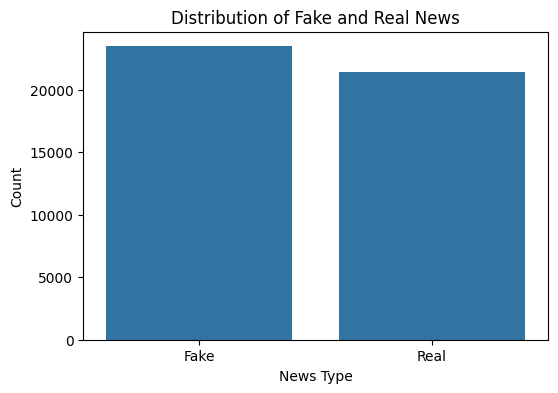

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=data)

plt.xticks([0,1], ['Fake', 'Real'])

plt.title("Distribution of Fake and Real News")

plt.xlabel("News Type")

plt.ylabel("Count")

plt.show()

Shows distribution of fake and real news articles.

##  Text Preprocessing

In [14]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'\[.*?\]', '', text)

    text = re.sub(
        r'https?://\S+|www\.\S+',
        '',
        text
    )

    text = re.sub(r'<.*?>+', '', text)

    text = re.sub(
        r'[%s]' % re.escape(string.punctuation),
        '',
        text
    )

    text = re.sub(r'\n', '', text)

    text = re.sub(r'\w*\d\w*', '', text)

    return text

This removes:

punctuation,
URLs,
special characters,
numbers

##  Applying Text Cleaning

In [15]:
data["text"] = data["text"].apply(clean_text)

Applies cleaning function to all text rows.

##  Features and Labels

In [16]:
x = data["text"]

y = data["label"]

x → input text

y → output labels

##  TF-IDF Vectorization

In [17]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

xv = vectorizer.fit_transform(x)

Converts text into numerical vectors.

##  Splitting Dataset

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    xv,
    y,
    test_size=0.25,
    random_state=42
)

75% → training data

25% → testing data

##  Logistic Regression Model

In [19]:
LR = LogisticRegression(max_iter=1000)

LR.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

Trains Logistic Regression model.

##  Model Evaluation

In [20]:
pred_lr = LR.predict(x_test)

lr_score = accuracy_score(y_test, pred_lr)

print("Accuracy :", lr_score)

Accuracy : 0.9851224944320712


Measures prediction accuracy.

##  Classification Report

In [21]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5819
           1       0.98      0.99      0.98      5406

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



Displays:

precision,
recall,
F1-score

##  Confusion Matrix

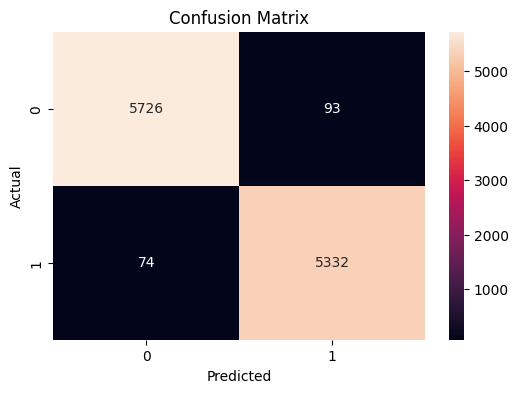

In [22]:
cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Shows correct and incorrect predictions.

##  Manual Prediction System

In [23]:
def manual_testing(news):

    testing_news = pd.DataFrame(
        {"text":[news]}
    )

    testing_news["text"] = testing_news["text"].apply(clean_text)

    new_x_test = vectorizer.transform(
        testing_news["text"]
    )

    prediction = LR.predict(new_x_test)

    if prediction[0] == 0:
        return "Fake News"

    else:
        return "Real News"

Allows custom news prediction.

##  Testing Model

In [24]:
news = """
The White House announced new economic policies on Tuesday to improve employment growth and strengthen international trade relations.
"""

print(manual_testing(news))

Real News


In [25]:
news = """
Aliens are secretly controlling world governments through hidden underground military bases beneath the oceans.
"""

print(manual_testing(news))

Fake News


##  Conclusion

In this project:
- Fake and real news datasets were analyzed
- NLP preprocessing techniques were applied
- TF-IDF vectorization converted text into numerical features
- Logistic Regression model was trained and evaluated
- The model successfully classified fake and real news articles

This project demonstrates:
- Natural Language Processing
- Machine Learning
- Text Classification
- Data Visualization

#  Overall Project Summary

In this project, a Fake News Detection system was developed using Natural Language Processing (NLP) and Machine Learning techniques.

The project began with loading and analyzing fake and real news datasets. Exploratory Data Analysis (EDA) was performed to understand the dataset structure, data distribution, and missing values.

Text preprocessing techniques were applied to clean the news articles by removing:
- punctuation
- URLs
- special characters
- numbers
- unnecessary text elements

The cleaned textual data was then converted into numerical form using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization. This helped the machine learning model understand the importance of words in the news articles.

The dataset was split into training and testing sets. A Logistic Regression model was trained on the training data to classify news articles as Fake News or Real News.

Model performance was evaluated using:
- Accuracy Score
- Classification Report
- Confusion Matrix

Finally, a manual prediction system was created where users can enter custom news text and receive predictions from the trained model.

The project demonstrates practical implementation of:
- Natural Language Processing (NLP)
- Text preprocessing
- Machine Learning classification
- Data visualization
- Model evaluation techniques